In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import nc_time_axis

from xgcm import Grid

import cftime
import cf_units
import datetime

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
import os,sys,time
import glob
import math
##warnings.filterwarnings("ignore")

# only for convenience dealing with CESM global model runs
sys.path.append("/glade/u/home/bryan/MOM6-modeloutputanalysis/Util/")
import make_case_dict
import fob_mom6_util as fmu   

In [34]:
casename = 'EEP_MITgcm185Lvgrid_Whitt2026hgrid'
path = '/glade/derecho/scratch/iranjan/archive/' + casename + '/ocn/hist/'

In [35]:
files = casename + '.mom6.h.z.2015-08-*.nc'

In [36]:
ds = xr.open_mfdataset(path+files,drop_variables=["average_DT",])

In [37]:
# My case didn't have volume transports in z-output. Calculate from mass transports
ds['uh'] = ds['umo']/1035.   # kg /s to m^3 /s
ds['vh'] = ds['vmo']/1035. 

# Fix the annoying difference in variable names for the vertical coordinate
ds = ds.rename({'z_l':'zl','z_i':'zi'})


In [38]:
ds['w_est1'] = ds['vert_remap_h_tendency'].cumsum(dim='zl')

In [39]:
ds

<xarray.Dataset> Size: 383GB
Dimensions:                         (time: 248, zl: 38, yh: 288, xq: 901,
                                     yq: 289, xh: 900, zi: 39, nbnd: 2)
Coordinates:
  * time                            (time) datetime64[ns] 2kB 2015-07-30T01:3...
  * zl                              (zl) float64 304B 2.5 10.0 ... 7.5e+03 8e+03
  * yh                              (yh) float64 2kB -11.96 -11.88 ... 11.96
  * xq                              (xq) float64 7kB 190.0 190.1 ... 264.9 265.0
  * yq                              (yq) float64 2kB -12.0 -11.92 ... 11.92 12.0
  * xh                              (xh) float64 7kB 190.0 190.1 ... 264.9 265.0
  * zi                              (zi) float64 312B 0.0 5.0 ... 8.25e+03
  * nbnd                            (nbnd) float64 16B 1.0 2.0
Data variables: (12/42)
    uo                              (time, zl, yh, xq) float32 10GB dask.array<chunksize=(8, 38, 288, 901), meta=np.ndarray>
    vo                              (time, zl, yq, xh) float32 10GB dask.array<chunksize=(8, 38, 289, 900), meta=np.ndarray>
    thetao                          (time, zl, yh, xh) float32 10GB dask.array<chunksize=(8, 38, 288, 900), meta=np.ndarray>
    so                              (time, zl, yh, xh) float32 10GB dask.array<chunksize=(8, 38, 288, 900), meta=np.ndarray>
    rhopot0                         (time, zl, yh, xh) float32 10GB dask.array<chunksize=(8, 38, 288, 900), meta=np.ndarray>
    vmo                             (time, zl, yq, xh) float32 10GB dask.array<chunksize=(8, 38, 289, 900), meta=np.ndarray>
    ...                              ...
    average_T1                      (time) datetime64[ns] 2kB dask.array<chunksize=(8,), meta=np.ndarray>
    average_T2                      (time) datetime64[ns] 2kB dask.array<chunksize=(8,), meta=np.ndarray>
    time_bounds                     (time, nbnd) datetime64[ns] 4kB dask.array<chunksize=(8, 2), meta=np.ndarray>
    uh                              (time, zl, yh, xq) float32 10GB dask.array<chunksize=(8, 38, 288, 901), meta=np.ndarray>
    vh                              (time, zl, yq, xh) float32 10GB dask.array<chunksize=(8, 38, 289, 900), meta=np.ndarray>
    w_est1                          (time, zl, yh, xh) float32 10GB dask.array<chunksize=(8, 38, 288, 900), meta=np.ndarray>
Attributes:
    NumFilesInSet:     1
    title:             MOM6 diagnostic fields table for CESM case: EEP_MITgcm...
    associated_files:  areacello: EEP_MITgcm185Lvgrid_Whitt2026hgrid.mom6.h.s...
    grid_type:         regular
    grid_tile:         N/A

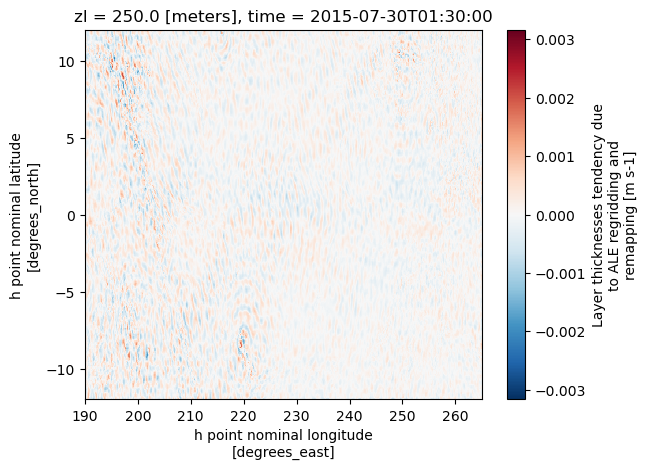

In [40]:
ds['w_est1'].isel(time=0,zl=10).plot()

In [41]:
def mean_w_est_box(ds: xr.Dataset, 
                   center_lat: float,
                   center_lon: float,
                   box_size:) -> xr.DataArray:
    half = box_size / 2.0
    #borders of this box
    lat_min = center_lat - half
    lat_max = center_lat + half
    lon_min = center_lon - half
    lon_max = center_lon + half
    
    w = ds['w_est1'].sel(
        yh=slice(lat_min, lat_max),
        xh=slice(lon_min, lon_max)
    )
    
    n_lat = w.sizes['yh']
    n_lon = w.sizes['xh']
    print(f"Box contains {n_lat} x {n_lon} grid cells")
    print(f"Lat range: {float(w.yh.min()):.3f} to {float(w.yh.max()):.3f}")
    print(f"Lon range: {float(w.xh.min()):.3f} to {float(w.xh.max()):.3f}")
    print(f"Time steps: {w.sizes['time']}")

    if n_lat == 0 or n_lon == 0:
        raise ValueError(
            f"No grid cells found in box. Check lon convention — "
            f"MOM6 uses 0-360, so 140W = 220E. "
            f"Your xh range is {float(ds.xh.min()):.1f} to {float(ds.xh.max()):.1f}"
        )
    w_mean = w.mean(dim=['time', 'yh', 'xh'])

    return w_mean

In [47]:
w_profile = mean_w_est_box(ds, center_lat=0.5, center_lon=220.0, box_size=1.0)

Box contains 12 x 12 grid cells
Lat range: 0.042 to 0.958
Lon range: 219.542 to 220.458
Time steps: 248


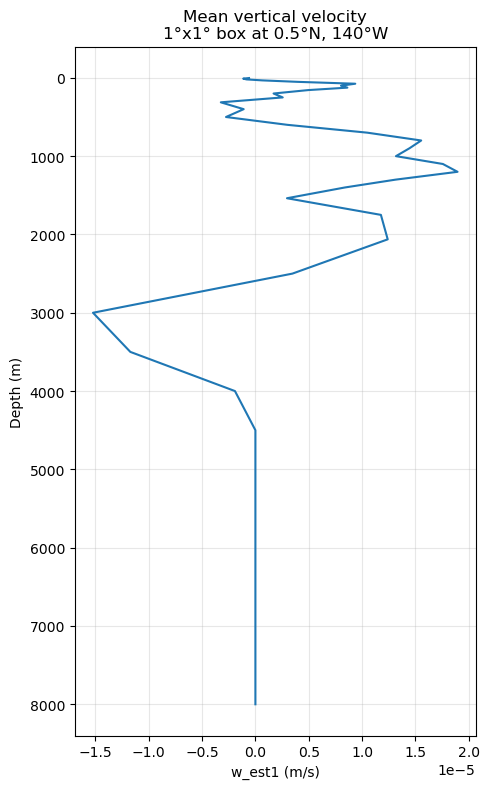

In [48]:
fig, ax = plt.subplots(figsize=(5, 8))
ax.plot(w_profile.values, w_profile.zl.values)
ax.invert_yaxis()
ax.set_xlabel('w_est1 (m/s)')
ax.set_ylabel('Depth (m)')
ax.set_title('Mean vertical velocity\n1°x1° box at 0.5°N, 140°W')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
def weekly_mean_w_est_profile(ds: xr.Dataset,
                               center_lat: float,
                               center_lon: float,
                               box_size: float) -> xr.Dataset:
    """
    Calculates weekly mean vertical profiles of w_est1 within a 1x1 degree
    box, returning a dataset with dimensions (week, zl).

    Args:
        ds (xr.Dataset): MOM6 h.z dataset containing w_est1. Must have
            dimensions (time, zl, yh, xh).
        center_lat (float): Center latitude of box in degrees N. 
        center_lon (float): Center longitude in degrees E (0-360).
        box_size (float): Full width/height of box in degrees.

    Returns:
        xr.Dataset: Dataset with dimensions (week, zl) containing:
            - w_est1_mean: weekly mean w_est1 profile
            - w_est1_std: weekly standard deviation profile
            - week_start: datetime of the start of each week
            - n_timesteps: number of 3-hourly timesteps in each week
    """
    half = box_size / 2.0

    # Spatial subset
    w = ds['w_est1'].sel(
        yh=slice(center_lat - half, center_lat + half),
        xh=slice(center_lon - half, center_lon + half)
    )

    n_lat = w.sizes['yh']
    n_lon = w.sizes['xh']
    print(f"Box: {n_lat} x {n_lon} grid cells")
    print(f"Lat: {float(w.yh.min()):.3f} to {float(w.yh.max()):.3f}")
    print(f"Lon: {float(w.xh.min()):.3f} to {float(w.xh.max()):.3f}")

    if n_lat == 0 or n_lon == 0:
        raise ValueError(
            f"No grid cells in box. xh range is "
            f"{float(ds.xh.min()):.1f} to {float(ds.xh.max()):.1f}. "
            f"Remember MOM6 uses 0-360 lon, so 140W = 220E."
        )

    # Mask below-seafloor zeros before averaging
    w_masked = w.where(w != 0.0)

    # Horizontal mean first -> (time, zl)
    w_horiz = w_masked.mean(dim=['yh', 'xh'])

    # Resample to weekly means
    w_weekly_mean = w_horiz.resample(time='1W').mean(dim='time')
    w_weekly_std  = w_horiz.resample(time='1W').std(dim='time')
    w_weekly_count = w_horiz.resample(time='1W').count(dim='time')

    # Week start times
    week_starts = w_weekly_mean.time.values

    # Build output dataset
    out_ds = xr.Dataset(
        {
            'w_est1_mean': (['week', 'zl'], w_weekly_mean.values),
            'w_est1_std':  (['week', 'zl'], w_weekly_std.values),
            'n_timesteps': (['week'], w_weekly_count.isel(zl=0).values),
            'week_start':  (['week'], week_starts),
        },
        coords={
            'week': np.arange(len(week_starts)),
            'zl':   ds['zl'].values,
        },
        attrs={
            'center_lat': center_lat,
            'center_lon': center_lon,
            'box_size':   box_size,
            'description': f'Weekly mean w_est1 profiles in {box_size}x{box_size} '
                           f'degree box centered at {center_lat}N, {center_lon}E',
        }
    )

    return out_ds

In [45]:
weekly_ds = weekly_mean_w_est_profile(ds, center_lat=0.5, center_lon=220.0, box_size=1)


Box: 12 x 12 grid cells
Lat: 0.042 to 0.958
Lon: 219.542 to 220.458


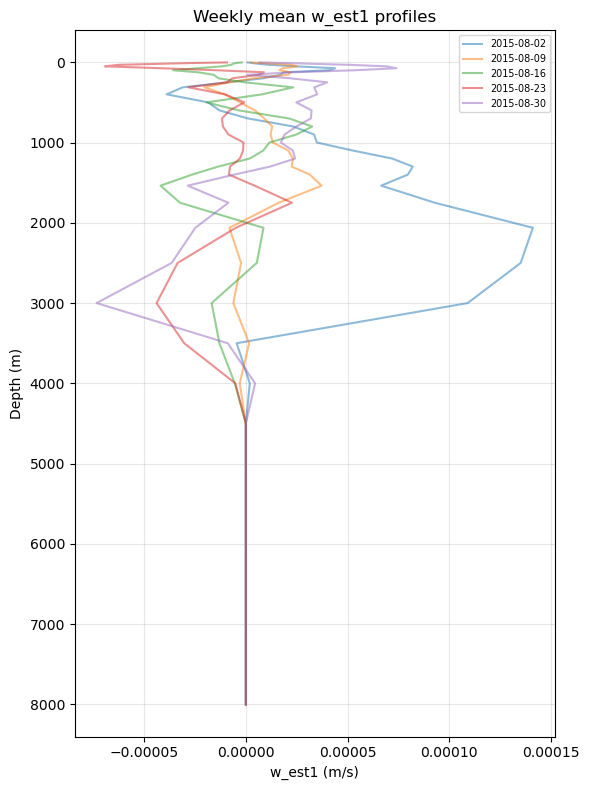

In [46]:
fig, ax = plt.subplots(figsize=(6, 8))
for week in weekly_ds.week.values:
    ax.plot(weekly_ds['w_est1_mean'].sel(week=week),
            weekly_ds.zl,
            alpha=0.5, label=str(weekly_ds['week_start'].sel(week=week).values)[:10])
ax.invert_yaxis()
ax.set_xlabel('w_est1 (m/s)')
ax.set_ylabel('Depth (m)')
ax.set_title('Weekly mean w_est1 profiles')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()